# Training Neural Network Models using BayesCompare

In this tutorial we will work on an example to use BayesCompare metrics in our loss for training a neural network. We will use a ImageNet pre-trained ResNet18 and fine-tune it on the Caltech101 dataset using a custom composite loss of cross entropy loss and a representational loss. For the representational part of our loss, we will compute the symmetrized KL divergence between the last fully connected layer of our ResNet and the idealized representation matrix for that batch of inputs. 

In [ ]:
import torch
import numpy as np
import tqdm

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torchvision.models import resnet18, ResNet18_Weights

from BayesCompare import measure_dist, cov_extractor

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)
torch_gen = torch.Generator()
torch_gen.manual_seed(SEED)

# Define constants for the training
BATCH_SIZE = 32
EPOCHS = 5

# We can use cuda for training if it is available
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

##### Helper Functions

In [2]:
def make_stratified_split(targets, val_fraction=0.2, seed=42):
    """
    Split every class independently so that each class is
    represented proportionally in both train and validation.
    """
    targets = np.asarray(targets)

    rng = np.random.default_rng(seed)

    train_indices = []
    val_indices = []
    display_indices = []

    for class_id in np.unique(targets):
        class_indices = np.where(targets == class_id)[0]
        # display_indices.extend(class_indices[:3]) if class_id in [5, 12, 55] else None
        display_indices.extend(class_indices[:3]) if class_id in [22, 56, 89] else None
        rng.shuffle(class_indices)

        n_val = int(round(len(class_indices) * val_fraction))
        val_indices.extend(class_indices[:n_val])
        train_indices.extend(class_indices[n_val:])

    # Sort so that the split itself does not depend on the order
    # in which classes were processed.
    train_indices = sorted(train_indices)
    val_indices = sorted(val_indices)

    return train_indices, val_indices, display_indices


def compute_idealized_representation(targets):
    return torch.matmul(targets, targets.T)
    
def tensor_to_image(x):
    # x = x.detach().cpu()

    # Undo ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    x = x.numpy().transpose(1, 2, 0)  # C,H,W -> H,W,C
    x = x * std + mean

    return np.clip(x, 0, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, targets in loader:
        
        images = images.to(device)
        targets = targets.to(device)
        
        covs_last_layer = cov_extractor(
                    model=model,
                    inputs=images,
                    layer_list=["linear_1_69"],
                    random_seed=42,
                    compute_covs=True,
                    gradient=True,
                    save_raw_output=True,
                )
        idealized_representation = compute_idealized_representation(torch.nn.functional.one_hot(targets, num_classes=101).float())
        dist_val = measure_dist([covs_last_layer["linear_1_69"], idealized_representation],
                    meas_name="kldiv",
                    b=0.1,
                    show_progress=False,
                )
        CE_loss = criterion(covs_last_layer["output_1"], targets)
        custom_loss = dist_val[0, 1] + CE_loss
        
        predictions = covs_last_layer["output_1"].argmax(dim=1)
        
        batch_size = images.size(0)
        total_loss += custom_loss.item() * batch_size

        total_correct += (predictions == targets).sum().item()
        total_samples += batch_size

    mean_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return mean_loss, accuracy

def plot_idealized_representation(images, representation):
    n = 9
    
    fig = plt.figure(figsize=(9, 9))

    gs = GridSpec(
        nrows=n + 1,
        ncols=n + 1,
        figure=fig,
        width_ratios=[1.5] + [1] * n,
        height_ratios=[1.5] + [1] * n,
        wspace=0.02,
        hspace=0.02
    )

    ax_matrix = fig.add_subplot(gs[1:, 1:])
    im = ax_matrix.imshow(
        representation,
        cmap="bone",
        vmin=0,
        vmax=1,
        interpolation="none"
    )

    ax_matrix.set_xticks([])
    ax_matrix.set_yticks([])

    # cell boundaries
    ax_matrix.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax_matrix.set_yticks(np.arange(-0.5, n, 1), minor=True)

    ax_matrix.grid(
        which="minor",
        linewidth=0.5,
        alpha=0.4
    )
    ax_matrix.tick_params(which="minor", bottom=False, left=False)

    # Images corresponding to columns
    for i, image in enumerate(images):
        ax = fig.add_subplot(gs[0, i + 1])

        ax.imshow(image)
        ax.axis("off")

    # Images corresponding to rows
    for i, image in enumerate(images):
        ax = fig.add_subplot(gs[i + 1, 0])

        ax.imshow(image)
        ax.axis("off")

    plt.show()

    return fig, ax_matrix

### Loading the model

We will first load the pretrained model and change its last fully connected layer to have 101 output classes for Caltech101.

In [7]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
# setting all parameters to not require gradients as we will only train the final layer for the Caltech101 dataset
for param in model.parameters():
    param.requires_grad = False
# modifying the final fully connected layer to have 101 output classes for the Caltech101 dataset
model.fc = torch.nn.Linear(model.fc.in_features, 101)
model = model.to(device)

### Loading the dataset

In [4]:
transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

full_dataset = datasets.Caltech101(
    root="./data",
    target_type="category",
    transform=transform,
    download=True,
)

NUM_CLASSES = len(full_dataset.categories)

print(f"Number of images: {len(full_dataset)}")
print(f"Number of classes: {NUM_CLASSES}")

train_indices, val_indices, display_indices = make_stratified_split(
    full_dataset.y,
    val_fraction=0.20,
    seed=SEED,
)

train_dataset = Subset(
    full_dataset,
    train_indices,
)

val_dataset = Subset(
    full_dataset,
    val_indices,
)

train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=5,
        generator=torch_gen,
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=5,
)

print(f"Training images:   {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")

Number of images: 8677
Number of classes: 101
Training images:   6941
Validation images: 1736


### Examining the idealized representations for some samples

Let's have a look at an idealized covariance matrix at the output for a set of inputs we have here. For illustration, we selected 3 samples from 3 classes of our dataset. An idealized representation of this image batch should be a 9x9 matrix where 3x3 diagonal blocks are identity, as those correspond to samples from the same class, and the off-diagonal blocks are all zero.

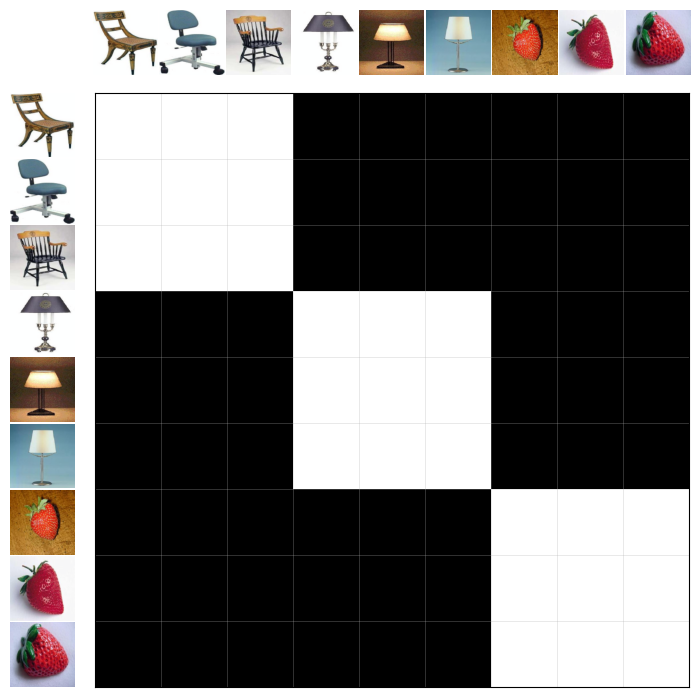

(<Figure size 900x900 with 19 Axes>, <Axes: >)

In [5]:
# creating the idealized representation matrix for the selected display images
sample_ideal_rep_mtx = compute_idealized_representation(
    torch.nn.functional.one_hot(
        torch.tensor([0, 0, 0, 1, 1, 1, 2, 2, 2]), num_classes=3
    ).float()
)

display_images = [
    tensor_to_image(full_dataset[display_indices[i]][0])
    for i in range(9)
]

plot_idealized_representation(display_images, sample_ideal_rep_mtx)

### Training the model

Now we will train our network with the representational distance of its outputs to the idelized representation covariance as explined above, along with the classification error. We chose KL divergence as our metric and set `b=0.1`. You may try different distances within BayesCompare and investigate how changing the noise parameter `b` affects the accuracy of the trained network.

In [6]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

for epoch in tqdm.tqdm(range(EPOCHS), desc=f"Training with representational loss", unit="epoch"):
        
        model.train()
        
        running_loss_class = 0.0
        running_loss_rep = 0.0
        running_correct = 0
        running_samples = 0

        for images, targets in train_loader:
            optimizer.zero_grad()
            
            images = images.to(device)
            targets = targets.to(device)
            
            # extract the covariance from the last fully connected layer while retaining the gradients and output of the network
            covs_last_layer = cov_extractor(
                        model=model,
                        inputs=images,
                        layer_list=["linear_1_69"],
                        random_seed=42,
                        compute_covs=True,    # compute covs from the selected layer activations
                        gradient=True,        # keep the gradients of this forward pass
                        save_network_output=True, # keep the output of the network for this forward pass
                    )
            
            # creat the idealized representation covariance matrix
            idealized_representation = compute_idealized_representation(torch.nn.functional.one_hot(targets, num_classes=101).float())
            
            # compute the distance between the idealized representation and the output layer representation of ResNet18
            dist_val = measure_dist([covs_last_layer["linear_1_69"], idealized_representation],
                        meas_name="kldiv",
                        b=0.1,
                        show_progress=False,
                    )
            
            # to access the logits of the network, we use the key "output_1" as per torchlens conventions
            CE_loss = criterion(covs_last_layer["output_1"], targets)
            
            # we are defining here out custom loss that consist of the representational distance 
            # and the cross entropy loss for the classification task. Since disdt_val gives us a 
            # symmetric matrix of shape (2, 2) we can access the value of the representational distance 
            # between idealized representation and the representation of the last layer by indexing it with [0, 1]
            custom_loss = dist_val[0, 1] + CE_loss
            
            batch_size = images.size(0)
            running_loss_class += CE_loss.item() * batch_size
            running_loss_rep += dist_val[0, 1] * batch_size
            
            predictions = covs_last_layer["output_1"].argmax(dim=1)
            running_correct += (predictions == targets).sum().item()
            running_samples += batch_size
            
            custom_loss.backward()
            
            optimizer.step()

        scheduler.step()
        
        train_loss_class = running_loss_class / running_samples
        train_loss_rep = running_loss_rep / running_samples
        train_accuracy = running_correct / running_samples
        
        val_loss, val_accuracy = evaluate(
            model,
            val_loader,
            criterion,
            device
        )
    
        print(
            f"ResNet18 Rep. Training | "
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"Classification train loss {train_loss_class:.4f} | "
            f"Representation train loss {train_loss_rep:.4f} | "
            f"Train acc {train_accuracy:.4f} | "
            f"Val loss {val_loss:.4f} | "
            f"Val acc {val_accuracy:.4f}"
        )

Training with representational loss:  20%|██        | 1/5 [00:45<03:00, 45.25s/epoch]

ResNet18 Rep. Training | Epoch 01/5 | train loss classification 4.1018 | train loss representation 0.3784 | train acc 0.1975 | val loss 4.0621 | val acc 0.3318


Training with representational loss:  40%|████      | 2/5 [01:33<02:21, 47.17s/epoch]

ResNet18 Rep. Training | Epoch 02/5 | train loss classification 3.1827 | train loss representation 0.3418 | train acc 0.4102 | val loss 3.2921 | val acc 0.5012


Training with representational loss:  60%|██████    | 3/5 [02:26<01:39, 49.67s/epoch]

ResNet18 Rep. Training | Epoch 03/5 | train loss classification 2.6295 | train loss representation 0.3436 | train acc 0.5463 | val loss 2.8650 | val acc 0.5950


Training with representational loss:  80%|████████  | 4/5 [03:28<00:54, 54.44s/epoch]

ResNet18 Rep. Training | Epoch 04/5 | train loss classification 2.3517 | train loss representation 0.3462 | train acc 0.6218 | val loss 2.6995 | val acc 0.6336


Training with representational loss: 100%|██████████| 5/5 [04:26<00:00, 53.28s/epoch]

ResNet18 Rep. Training | Epoch 05/5 | train loss classification 2.2421 | train loss representation 0.3451 | train acc 0.6475 | val loss 2.6509 | val acc 0.6544


We learned in this tutorial how to use representational distances we obtain with BayesCompare to train our networks. To retain the gradients and possibly compute losses over our outputs, we need to set the parameters of the `cov_extractor` function as follows:

| Parameter name | Effect |  
|---|---|
| `compute_covs` | Set `True` to get the covariances to compute representational distances |
| `gradient` | Set `True` to retain the graph and the gradients connected to the it | 
| `save_raw_output` | Set `True` to keep the activations of the output layer | 